# IMPORT LIBRARIES

In [ ]:
%matplotlib inline

# import warnings
# warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from collections import defaultdict
from itertools import cycle
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split

from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# from yellowbrick import ROCAUC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn import tree

from IPython.display import Image
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder


from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
# from scikitplot.metrics import plot_roc

import utils

In [3]:
from sklearn.decomposition import PCA
from scipy.stats import randint as sp_randint
from sklearn.metrics import make_scorer

# PREP AND SPLIT

In [4]:
df = pd.read_csv("dataset/train_post_outlier.csv")
df.shape

(115507, 61)

In [5]:
df = df.drop(columns="Unnamed: 0")

In [6]:
X = df.drop(columns=["rating_category", "averageRating"])
y = df["rating_category"]


In [7]:
encoder = LabelEncoder()
# First fit the encoder on the data
encoder.fit_transform(y)

mapping = dict(zip(encoder.classes_, range(len(encoder.classes_))))

# Print the mapping
print("Mapping of Genres:")
for genre, code in mapping.items():
    print(f"{genre}: {code}")

# Example decoding
decoded_code = 1  # Example code to decode
decoded_emotion = encoder.inverse_transform([decoded_code])[0]
print(f"\nMapping of Genre {decoded_code}: {decoded_emotion}")


Mapping of Genres:
High: 0
Low: 1
Medium: 2
Very High: 3
Very Low: 4

Mapping of Genre 1: Low


In [8]:
y = encoder.transform(y)

In [9]:
classes = np.unique(y)
classes

array([0, 1, 2, 3, 4])

In [10]:
mapping


{'High': 0, 'Low': 1, 'Medium': 2, 'Very High': 3, 'Very Low': 4}

In [11]:
# Split but I'll do a cross validation later
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

 # RANDOM FOREST
 

In [55]:
from sklearn.ensemble import RandomForestClassifier

Cosa vado a fare: <br>
- Hyper-parameter tuning su tutto l'x_test con la random search e vado ad allenare il modello con i parametri migliori, stampando il classification report;
- Vado a vedere la feature importance per questo modello e faccio un dataset con solo le k feature che vengono considerate più importanti;
- Con il dataset con le k feature più importanti vado a fare di nuovo hyper parameter tuning, e a vedere l'accuracy;
- Su uno dei due vado a fare il plot dell'accuracy al variare del numero di stimatori che vengono usati - sarebbe molto bello fare il plot con entrambi sovrapposti, facendo vedere l'accuracy allenando su tutto e l'accuracy allenando invece soltanto su quelle migliori

In [56]:
param_list = {
    "n_estimators": [50, 100, 150, 200],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_depth": list(np.arange(2, 10)),
    "criterion": ["gini", "entropy", "log_loss"],
    "max_features": ["sqrt", "log2"],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=param_list,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)
random_search.best_params_


{'n_estimators': 50,
 'min_samples_split': 20,
 'min_samples_leaf': 5,
 'max_features': 'log2',
 'max_depth': np.int64(8),
 'criterion': 'gini'}

In [57]:
random_search.best_estimator_

RandomForestClassifier(max_depth=np.int64(8), max_features='log2',
                       min_samples_leaf=5, min_samples_split=20,
                       n_estimators=50)

In [59]:
# alleno il modello con i migliori parametri
%time
rfc1 = random_search.best_estimator_
rfc1.fit(X_train, y_train)

y_pred_rfc1 = rfc1.predict(X_test)

print("Accuracy %s" % accuracy_score(y_test, y_pred_rfc1))
print("F1-score %s" % f1_score(y_test, y_pred_rfc1, average="weighted"))
print(classification_report(y_test, y_pred_rfc1, target_names=mapping))

CPU times: user 1e+03 ns, sys: 1 μs, total: 2 μs
Wall time: 1.91 μs
Accuracy 0.35551034542463855
F1-score 0.28310066898986397
              precision    recall  f1-score   support

        High       0.31      0.74      0.44      5109
         Low       0.32      0.14      0.20      4748
      Medium       0.38      0.02      0.04      4510
   Very High       0.42      0.12      0.18      3992
    Very Low       0.42      0.67      0.52      4743

    accuracy                           0.36     23102
   macro avg       0.37      0.34      0.28     23102
weighted avg       0.37      0.36      0.28     23102



In [61]:
# Calcola l'accuratezza e altre metriche di valutazione del modello sia sui dati di addestramento che sui dati di test.

train_accuracy = accuracy_score(y_train, rfc1.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred_rfc1)
print("Accuratezza sul set di addestramento:", train_accuracy)
print("Accuratezza sul set di test:", test_accuracy)


Accuratezza sul set di addestramento: 0.3669606623018235
Accuratezza sul set di test: 0.35551034542463855


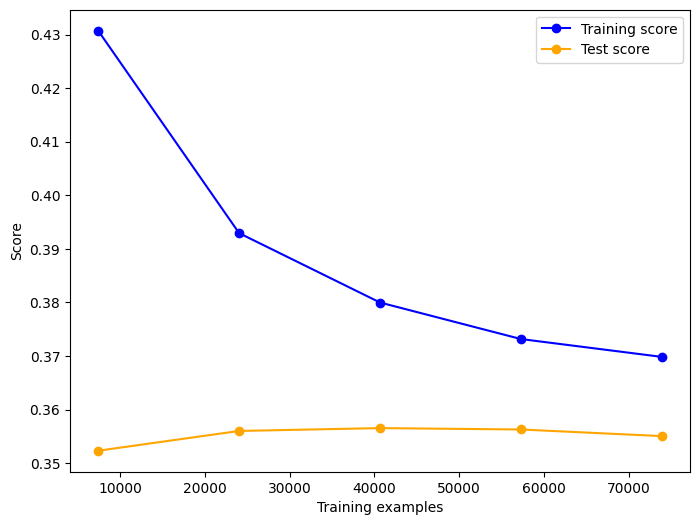

In [62]:
# Disegna le curve di apprendimento per valutare le prestazioni del modello al variare della dimensione
# del set di addestramento e confronta le prestazioni sul set di addestramento e di test.


plt.figure(
    figsize=(8, 6)
)  # Modifica le dimensioni come desiderato (larghezza, altezza)
train_sizes, train_scores, test_scores = learning_curve(rfc1, X_train, y_train, cv=5)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, "o-", label="Training score", color="blue")
plt.plot(train_sizes, test_scores_mean, "o-", label="Test score", color="orange")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()


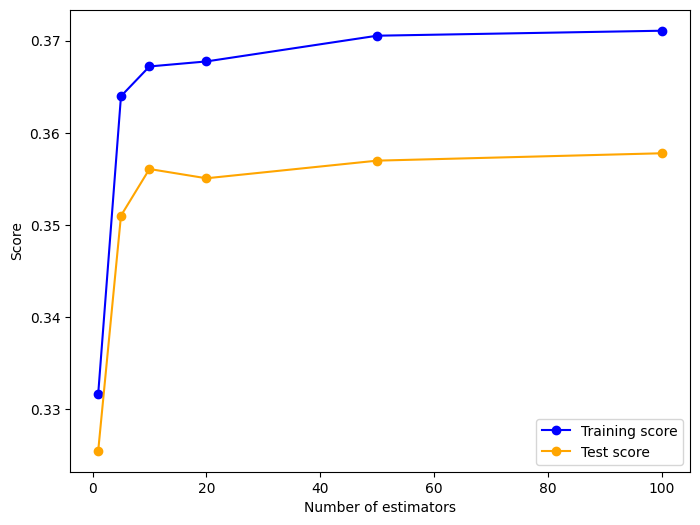

In [63]:
plt.figure(figsize=(8, 6))
param_range = [1, 5, 10, 20, 50, 100]  # Esempio di parametri da esplorare
train_scores, test_scores = validation_curve(
    rfc1, X_train, y_train, param_name="n_estimators", param_range=param_range, cv=5
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(param_range, train_scores_mean, "o-", label="Training score", color="blue")
plt.plot(param_range, test_scores_mean, "o-", label="Test score", color="orange")
plt.xlabel("Number of estimators")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()

In [64]:
import importlib

importlib.reload(utils)


<module 'utils' from '/Users/daviderizzello/Documents/Uni/DM2/Progetto/utils.py'>

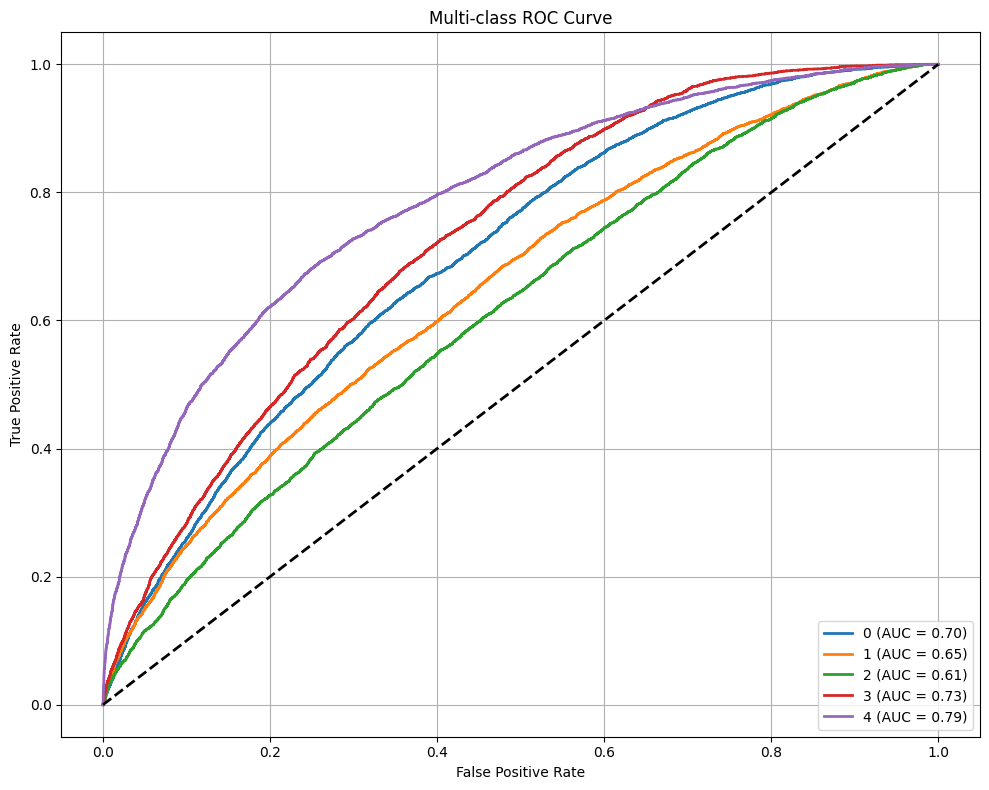

In [65]:
y_score_rfc1 = rfc1.predict_proba(X_test)
utils.plot_multiclass_roc(y_test, y_score_rfc1, class_names=classes)

plt.show()


array([[3794,  343,   54,  200,  718],
       [1853,  680,   37,  136, 2042],
       [2735,  534,   84,  152, 1005],
       [2709,  238,   25,  460,  560],
       [1036,  346,   19,  147, 3195]])

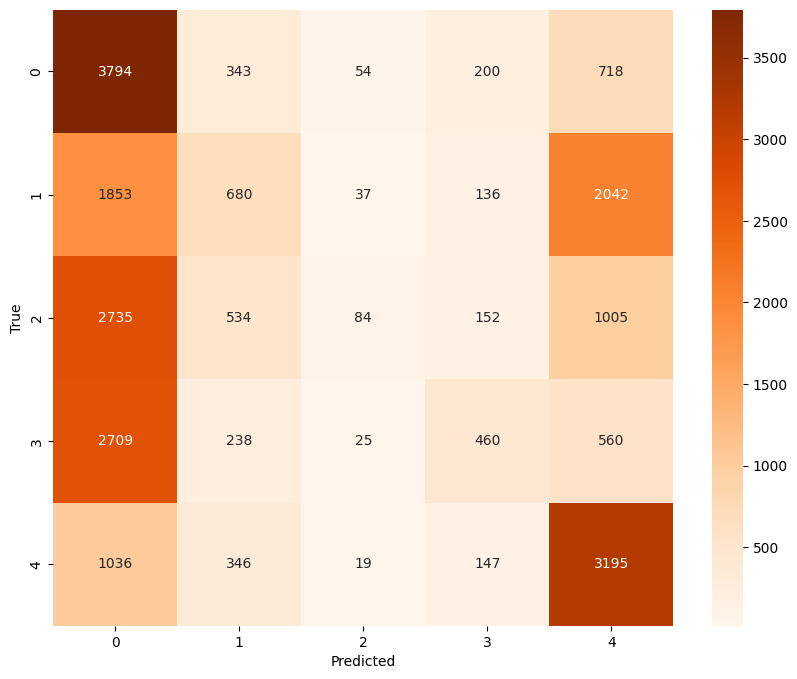

In [66]:
cm_rfc1 = confusion_matrix(y_test, y_pred_rfc1)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rfc1, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("True")
cm_rfc1

In [24]:
# Getting feature importance:
import json

json.dumps(classification_report(y_test, y_pred_rfc1, output_dict=True))

'{"0": {"precision": 0.6768020032194598, "recall": 0.6321416638823922, "f1-score": 0.6537099421266304, "support": 5986.0}, "1": {"precision": 0.6299079953349748, "recall": 0.738529322394409, "f1-score": 0.6799076858521574, "support": 6582.0}, "2": {"precision": 0.6903409090909091, "recall": 0.16886726893676163, "f1-score": 0.271356783919598, "support": 1439.0}, "3": {"precision": 0.7173537398173291, "recall": 0.7845572354211663, "f1-score": 0.7494519664732431, "support": 3704.0}, "accuracy": 0.6659138388572073, "macro avg": {"precision": 0.6786011618656682, "recall": 0.5810238726586823, "f1-score": 0.5886065945929073, "support": 17711.0}, "weighted avg": {"precision": 0.6689554535052621, "recall": 0.6659138388572073, "f1-score": 0.6524031730408278, "support": 17711.0}}'

In [25]:
json.loads(json.dumps(classification_report(y_test, y_pred_rfc1, output_dict=True)))

{'0': {'precision': 0.6768020032194598,
  'recall': 0.6321416638823922,
  'f1-score': 0.6537099421266304,
  'support': 5986.0},
 '1': {'precision': 0.6299079953349748,
  'recall': 0.738529322394409,
  'f1-score': 0.6799076858521574,
  'support': 6582.0},
 '2': {'precision': 0.6903409090909091,
  'recall': 0.16886726893676163,
  'f1-score': 0.271356783919598,
  'support': 1439.0},
 '3': {'precision': 0.7173537398173291,
  'recall': 0.7845572354211663,
  'f1-score': 0.7494519664732431,
  'support': 3704.0},
 'accuracy': 0.6659138388572073,
 'macro avg': {'precision': 0.6786011618656682,
  'recall': 0.5810238726586823,
  'f1-score': 0.5886065945929073,
  'support': 17711.0},
 'weighted avg': {'precision': 0.6689554535052621,
  'recall': 0.6659138388572073,
  'f1-score': 0.6524031730408278,
  'support': 17711.0}}

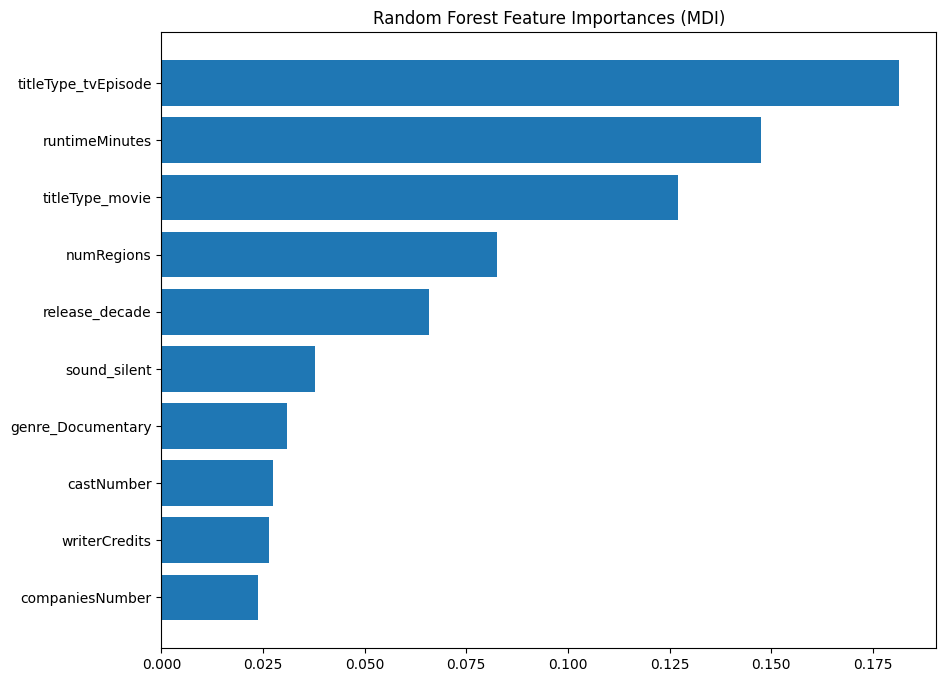

['companiesNumber' 'writerCredits' 'castNumber' 'genre_Documentary'
 'sound_silent' 'release_decade' 'numRegions' 'titleType_movie'
 'runtimeMinutes' 'titleType_tvEpisode']


In [67]:
nbr_features = 10
attributes = X_train.columns  # a separate list you kept of column names


tree_feature_importances = rfc1.feature_importances_
sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

y_ticks = np.arange(0, len(sorted_idx))
# fig, ax = plt.subplots()

plt.figure(figsize=(10, 8))
plt.barh(y_ticks, tree_feature_importances[sorted_idx])
plt.yticks(y_ticks, np.array(attributes)[sorted_idx])
plt.title("Random Forest Feature Importances (MDI)")
plt.show()
print(np.array(attributes)[sorted_idx])

In [70]:
important_columns = [
    "companiesNumber",
    "writerCredits",
    "castNumber",
    "genre_Documentary",
    "sound_silent",
    "release_decade",
    "numRegions",
    "titleType_movie",
    "runtimeMinutes",
    "titleType_tvEpisode",
]


In [71]:
import copy

df_impo = copy.deepcopy(df[important_columns])
df_impo.head()

,companiesNumber,writerCredits,castNumber,genre_Documentary,sound_silent,release_decade,numRegions,titleType_movie,runtimeMinutes,titleType_tvEpisode
0,0.00,0.0,-0.3125,0,0,0.666667,0.0,False,-0.500000,False
1,-0.25,0.0,-0.0625,0,0,0.666667,0.0,False,-0.557692,False
2,2.25,1.0,0.4375,0,0,-0.333333,0.0,False,0.134615,True
3,-0.25,0.0,-0.6875,0,0,0.666667,0.0,True,0.269231,False
4,-0.25,0.0,-0.5625,0,0,0.666667,0.0,False,-0.615385,False


In [72]:
x_ridotto = df_impo.values
df_impo.shape, y.shape

((115507, 10), (115507,))

In [73]:
from sklearn.model_selection import train_test_split

x_train_ridotto, x_test_ridotto, y_train, y_test = train_test_split(
    x_ridotto, y, test_size=0.2, random_state=42, stratify=y
)
# Usando l'opzione stratify=y, garantisci che la suddivisione mantenga la stessa proporzione di classi tra set di addestramento e di test, utile quando hai un set di dati sbilanciato

x_train_ridotto.shape, x_test_ridotto.shape, y_train.shape, y_test.shape

((92405, 10), (23102, 10), (92405,), (23102,))

In [74]:
param_list = {
    "n_estimators": [50, 100, 150, 200],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_depth": list(np.arange(2, 10)),
    "criterion": ["gini", "entropy", "log_loss"],
    "max_features": ["sqrt", "log2"],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=param_list,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
random_search.fit(x_train_ridotto, y_train)
random_search.best_params_

# I parametri migliori sono gli stessi del caso "intero"?

{'n_estimators': 50,
 'min_samples_split': 20,
 'min_samples_leaf': 5,
 'max_features': 'log2',
 'max_depth': np.int64(8),
 'criterion': 'gini'}

In [75]:
# alleno il modello con i migliori parametri
%time
rfc2 = random_search.best_estimator_
rfc2.fit(x_train_ridotto, y_train)

y_pred_rfc2 = rfc2.predict(x_test_ridotto)

print("Accuracy %s" % accuracy_score(y_test, y_pred_rfc2))
print("F1-score %s" % f1_score(y_test, y_pred_rfc2, average="weighted"))
print(classification_report(y_test, y_pred_rfc2, target_names=mapping))

# Con solamente 15 feature si  ottiene una accuracy di 0.415, invece di 0.4375 come il caso "intero"

CPU times: user 2 μs, sys: 2 μs, total: 4 μs
Wall time: 11.9 μs
Accuracy 0.36234958012293306
F1-score 0.3202939971071462
              precision    recall  f1-score   support

        High       0.33      0.61      0.43      5109
         Low       0.32      0.19      0.24      4748
      Medium       0.34      0.05      0.08      4510
   Very High       0.33      0.31      0.32      3992
    Very Low       0.44      0.62      0.51      4743

    accuracy                           0.36     23102
   macro avg       0.35      0.35      0.32     23102
weighted avg       0.35      0.36      0.32     23102



In [76]:
# Calcola l'accuratezza e altre metriche di valutazione del modello sia sui dati di addestramento che sui dati di test.

train_accuracy = accuracy_score(y_train, rfc2.predict(x_train_ridotto))
test_accuracy = accuracy_score(y_test, y_pred_rfc2)
print("Accuratezza sul set di addestramento:", train_accuracy)
print("Accuratezza sul set di test:", test_accuracy)

Accuratezza sul set di addestramento: 0.37935176667929227
Accuratezza sul set di test: 0.36234958012293306


In [77]:
# Vado a plottare l'accuracy dei due modelli al variare del numero di stimatori, che fino ad adesso è stato mantenuto di default = 100
# Mentre gli altri parametri li lasciamo come trovati nelle search

max_k = 200
min = 5
step = 5
acc_intero = []
acc_ridotto = []

for k in range(min, max_k + 1, step):
    rfc1 = RandomForestClassifier(
        n_estimators=k,
        criterion="gini",
        min_samples_leaf=5,
        min_samples_split=20,
        max_depth=8,
        max_features="log2",
        n_jobs=-1,
    )
    rfc2 = RandomForestClassifier(
        n_estimators=k,
        criterion="gini",
        min_samples_leaf=5,
        min_samples_split=20,
        max_depth=8,
        max_features="log2",
        n_jobs=-1,
    )
    rfc1.fit(X_train, y_train)
    rfc2.fit(x_train_ridotto, y_train)

    y_pred_rfc1 = rfc1.predict(X_test)
    y_pred_rfc2 = rfc2.predict(x_test_ridotto)

    acc_intero.append(accuracy_score(y_test, y_pred_rfc1))
    acc_ridotto.append(accuracy_score(y_test, y_pred_rfc2))

    print(f"{k}th fit done")


5th fit done
10th fit done
15th fit done
20th fit done
25th fit done
30th fit done
35th fit done
40th fit done
45th fit done
50th fit done
55th fit done
60th fit done
65th fit done
70th fit done
75th fit done
80th fit done
85th fit done
90th fit done
95th fit done
100th fit done
105th fit done
110th fit done
115th fit done
120th fit done
125th fit done
130th fit done
135th fit done
140th fit done
145th fit done
150th fit done
155th fit done
160th fit done
165th fit done
170th fit done
175th fit done
180th fit done
185th fit done
190th fit done
195th fit done
200th fit done


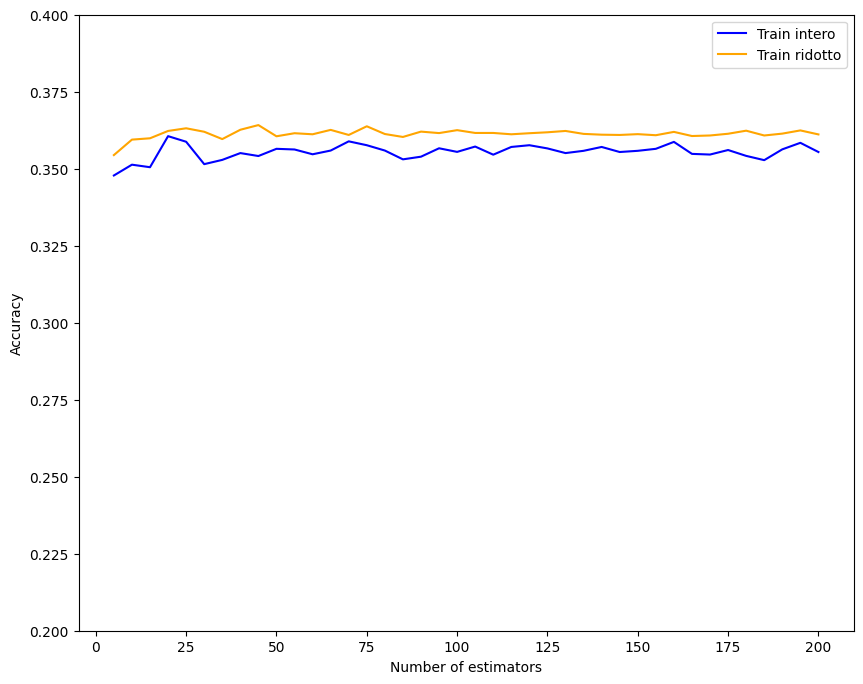

In [81]:
k_values = list(range(min, max_k + 1, step))

plt.figure(figsize=(10, 8))

# Plotting
plt.plot(k_values, acc_intero, label="Train intero", color="blue")
plt.plot(k_values, acc_ridotto, label="Train ridotto", color="orange")

# Adding labels and title
plt.xlabel("Number of estimators")
plt.ylabel("Accuracy")
plt.grid(False)
# Adding a legend
plt.legend()

plt.ylim(0.20, 0.4)  # Replace 0 and 1 with your desired y-axis range

# Display the plot
plt.show()

# BOOSTING

In [82]:
from sklearn.ensemble import AdaBoostClassifier

Cosa vado a fare: <br>
- Confrontare quello che fa il modello base (che usa i decision stump come base classifiers) e fare hyperparameter tuning su questi
- con quello che fa il modello se metto come base classifier RandomForest -> si riesce ad ottenere un modello più robusto, che migliora le prestazioni?
- Andare ad analizzare in qualche modo la feature importance dei due modelli - printarla e vedere se c'è qualcosa di interessante

In [83]:
# If None, then the base estimator is DecisionTreeClassifier initialized with max_depth=1.
abc1 = AdaBoostClassifier(estimator=None)

In [84]:
# quanti min

param_list = {
    "n_estimators": [50, 75, 100, 125],
    "learning_rate": [0.01, 0.1, 0.2, 0.3, 0.5],
    "algorithm": ["SAMME", "SAMME.R"],
}

random_search = RandomizedSearchCV(
    abc1, param_distributions=param_list, n_iter=10, cv=5, random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)
random_search.best_params_

/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in ve

{'n_estimators': 50, 'learning_rate': 0.3, 'algorithm': 'SAMME'}

In [85]:
abc1 = random_search.best_estimator_
abc1.fit(X_train, y_train)

y_pred_abc1 = abc1.predict(X_test)

print("Accuracy %s" % accuracy_score(y_test, y_pred_abc1))
print("F1-score %s" % f1_score(y_test, y_pred_abc1, average="weighted"))
print(classification_report(y_test, y_pred_abc1, target_names=mapping))

/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Accuracy 0.32027530083975414
F1-score 0.24270330123288428
              precision    recall  f1-score   support

        High       0.32      0.67      0.43      5109
         Low       0.23      0.27      0.25      4748
      Medium       0.00      0.00      0.00      4510
   Very High       0.00      0.00      0.00      3992
    Very Low       0.40      0.57      0.47      4743

    accuracy                           0.32     23102
   macro avg       0.19      0.30      0.23     23102
weighted avg       0.20      0.32      0.24     23102



/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

In [86]:
# Calcola l'accuratezza e altre metriche di valutazione del modello sia sui dati di addestramento che sui dati di test.

train_accuracy = accuracy_score(y_train, abc1.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred_abc1)
print("Accuratezza sul set di addestramento:", train_accuracy)
print("Accuratezza sul set di test:", test_accuracy)

Accuratezza sul set di addestramento: 0.3204155619284671
Accuratezza sul set di test: 0.32027530083975414


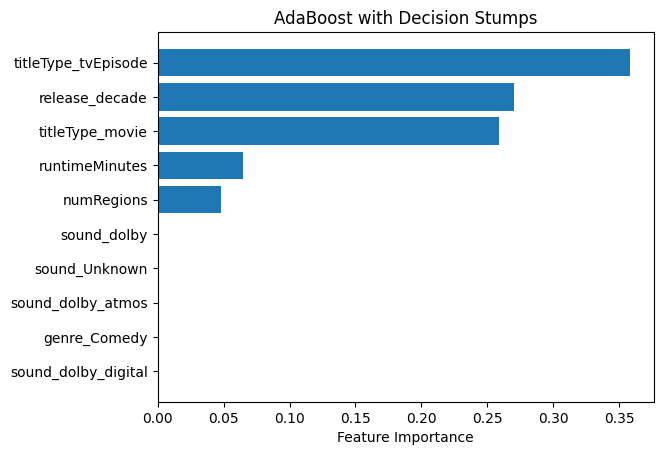

['sound_dolby_digital' 'genre_Comedy' 'sound_dolby_atmos' 'sound_Unknown'
 'sound_dolby' 'numRegions' 'runtimeMinutes' 'titleType_movie'
 'release_decade' 'titleType_tvEpisode']


In [87]:
nbr_features = 10

feature_importances_abc1 = abc1.feature_importances_
sorted_idx = feature_importances_abc1.argsort()[-nbr_features:]

y_ticks = np.arange(0, len(sorted_idx))
fig, ax = plt.subplots()
plt.barh(y_ticks, feature_importances_abc1[sorted_idx])
plt.yticks(y_ticks, np.array(attributes)[sorted_idx])
plt.title("AdaBoost with Decision Stumps")
plt.xlabel("Feature Importance")
plt.show()
print(np.array(attributes)[sorted_idx])

## gradient boosting e variazioni(xgboost - light - cat)


Gradient Boosting è una tecnica di ensemble learning che costruisce un modello predittivo complesso combinando insieme molteplici modelli più semplici, di solito chiamati weak learners. In questo contesto, un weak learner è un modello che ha prestazioni leggermente migliori di un modello casuale.

La tecnica di Gradient Boosting costruisce iterativamente i weak learners in modo sequenziale, enfatizzando gli errori commessi dai modelli precedenti. Ogni nuovo modello è addestrato per correggere gli errori del modello precedente. Questo viene fatto minimizzando una funzione di perdita, tipicamente attraverso gradient descent.

Ora, riguardo ai parametri usati nell'esempio di codice fornito:

n_estimators: Il numero di weak learners (alberi decisionali nel caso di Gradient Boosting) che vengono combinati. Un valore più alto potrebbe portare a un modello più complesso, ma bisogna fare attenzione a non incorrere in overfitting.

learning_rate: Il tasso di apprendimento controlla quanto ogni modello contribuisce alla correzione degli errori dei modelli precedenti. Valori più bassi rendono il modello più robusto, ma richiedono un maggior numero di weak learners.

max_depth: La massima profondità di ogni albero decisionale. Un valore più alto potrebbe portare a un modello più complesso, ma anche a un maggiore rischio di overfitting.

min_samples_split: Il numero minimo di campioni richiesti per suddividere un nodo interno dell'albero.

min_samples_leaf: Il numero minimo di campioni richiesti in una foglia dell'albero.

subsample: La frazione dei campioni da utilizzare per l'addestramento di ciascun albero. Valori più bassi possono aiutare a prevenire l'overfitting.

# GRADIENT BOOSTING

# XGBoost
https://xgboost.readthedocs.io/en/stable/python/python_intro.html

In [2]:
!python -c "import platform; print(platform.architecture())"

('64bit', '')


In [3]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [12]:
from xgboost import XGBClassifier

In [13]:
# Inizializzo il classificatore
xgb = XGBClassifier()

In [14]:
param_list = {  # 'objective': ['binary:logistic'],
    "n_estimators": [50, 75, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "gamma": [0.0, 0.1, 0.2],
    "reg_lambda": [0.0, 0.5, 1.0],  # L2 regularization
    "reg_alpha": [0.0, 0.5, 1.0],  # L1 regularization
    "tree_method": ["exact", "approx"],
    "booster": ["gbtree", "gblinear"],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    xgb, param_distributions=param_list, n_iter=10, cv=5, random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)
print(random_search.best_params_)

/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:23:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "colsample_bytree", "gamma", "max_depth", "subsample", "tree_method" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:23:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "colsample_bytree", "gamma", "max_depth", "subsample", "tree_method" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:23:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "colsample_bytree", "gamma", "max_depth", "subsample", "tree_method" } are not used.

  bst.update(dtrain, ite

{'tree_method': 'exact', 'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 150, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0.0, 'colsample_bytree': 0.6, 'booster': 'gbtree'}


In [15]:
xgb = random_search.best_estimator_
random_search.best_estimator_

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [16]:
# xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy %s" % accuracy_score(y_test, y_pred_xgb))
print("F1-score %s" % f1_score(y_test, y_pred_xgb, average=None))
print(classification_report(y_test, y_pred_xgb, target_names=mapping))

Accuracy 0.3950307332698468
F1-score [0.44135647 0.29298701 0.14925894 0.37621235 0.54889533]
              precision    recall  f1-score   support

        High       0.35      0.60      0.44      5109
         Low       0.38      0.24      0.29      4748
      Medium       0.35      0.09      0.15      4510
   Very High       0.38      0.37      0.38      3992
    Very Low       0.48      0.64      0.55      4743

    accuracy                           0.40     23102
   macro avg       0.39      0.39      0.36     23102
weighted avg       0.39      0.40      0.36     23102



In [17]:
# Calcola l'accuratezza e altre metriche di valutazione del modello sia sui dati di addestramento che sui dati di test.

train_accuracy = accuracy_score(y_train, xgb.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred_xgb)
print("Accuratezza sul set di addestramento:", train_accuracy)
print("Accuratezza sul set di test:", test_accuracy)

Accuratezza sul set di addestramento: 0.4581245603592879
Accuratezza sul set di test: 0.3950307332698468


In [18]:
# Plotto la ROC e la confusion matrix, giusto per averle
y_score_xgb = xgb.predict_proba(X_test)
# plot_roc(y_test, y_score_xgb, figsize=(10,8), title_fontsize=15, text_fontsize=13)
# plt.title("")
# plt.show()


array([[3065,  329,  299,  871,  545],
       [1258, 1128,  290,  493, 1579],
       [2044,  699,  428,  582,  757],
       [1848,  185,   96, 1474,  389],
       [ 565,  611,  112,  424, 3031]])

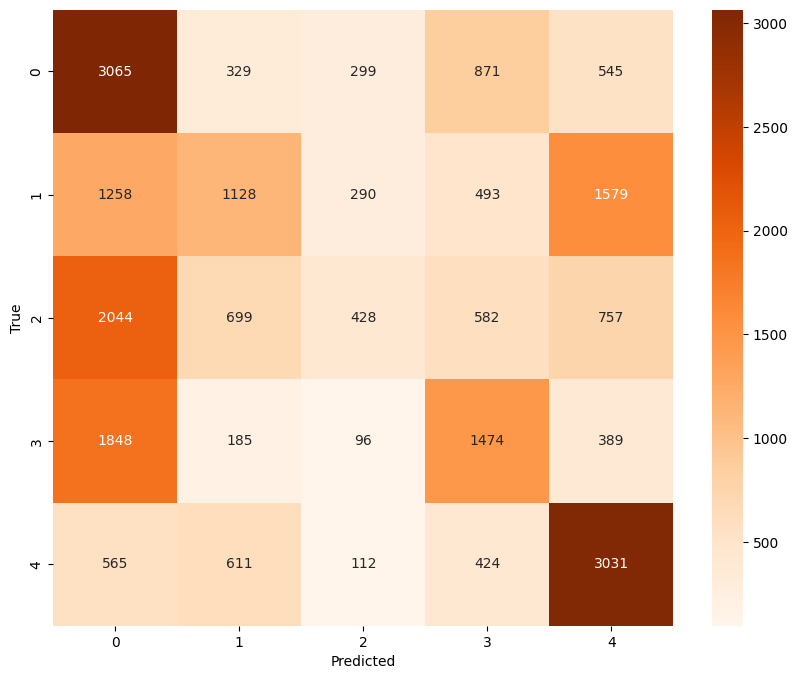

In [19]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("True")
cm_xgb

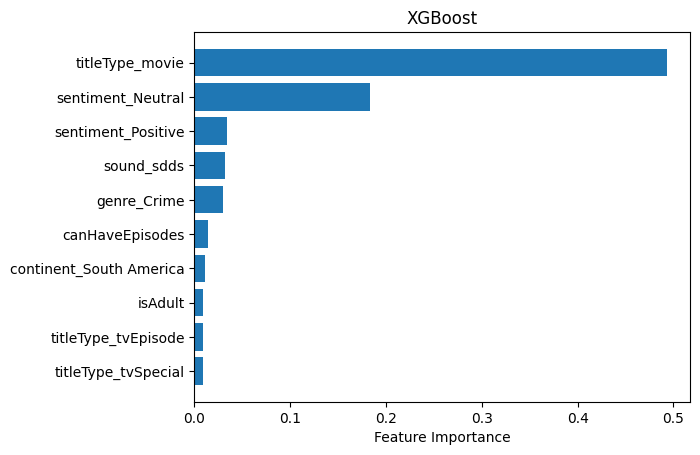

['titleType_tvSpecial' 'titleType_tvEpisode' 'isAdult'
 'continent_South America' 'canHaveEpisodes' 'genre_Crime' 'sound_sdds'
 'sentiment_Positive' 'sentiment_Neutral' 'titleType_movie']


In [20]:
# Prendiamo la feature importance delle prime 15 del modello migliore (XGBoost)
nbr_features = 10

feature_importances_xgb = xgb.feature_importances_
sorted_idx3 = feature_importances_xgb.argsort()[-nbr_features:]

y_ticks3 = np.arange(0, len(sorted_idx3))
fig, ax = plt.subplots()
plt.barh(y_ticks3, feature_importances_xgb[sorted_idx3])
plt.yticks(y_ticks3, np.array(df.columns)[sorted_idx3])
plt.title("XGBoost")
plt.xlabel("Feature Importance")
plt.show()
print(np.array(df.columns)[sorted_idx3])

In [21]:
for i in sorted_idx3:
    print(i, np.array(df.columns)[i], feature_importances_xgb[i])

57 titleType_tvSpecial 0.008501875
52 titleType_tvEpisode 0.009104032
3 isAdult 0.009237576
41 continent_South America 0.011040889
2 canHaveEpisodes 0.013765695
15 genre_Crime 0.029553488
30 sound_sdds 0.031713888
49 sentiment_Positive 0.034189872
48 sentiment_Neutral 0.18288471
50 titleType_movie 0.4931852


# LightGBM
https://lightgbm.readthedocs.io/en/latest/Python-Intro.html

In [22]:
!pip install lightgbm
# or use conda install -c conda-forge lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.4 MB/s eta 0:00:00


In [23]:
from lightgbm import LGBMClassifier

In [24]:
# Definisci il modello LGBMClassifier
lgbm = LGBMClassifier()

# Definisci la griglia dei parametri
param_grid = {
    "boosting_type": ["gbdt", "goss"],  # dart
    "n_estimators": [10, 20, 30, 50, 100, 200],  # 200
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],  #  [-1]   [3, 5, 7, 9 ]
    "subsample_for_bin": [200000],
    "objective": ["multiclass"],
    "min_data_in_leaf": [100, 200, 300, 1000, 2000],
    "num_leaves": [15, 31, 63],
    "reg_alpha": [0.0, 0.1, 0.3, 0.5],  # L1 regularization term on weights
    "reg_lambda": [0.0, 0.1, 0.3, 0.5],  # L2 regularization term on weights
}

# Crea l'oggetto RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
)

# Esegui la ricerca casuale dei parametri
random_search.fit(X_train, y_train)

# Stampare i migliori parametri trovati
print(random_search.best_params_)

[LightGBM] [Warning] min_data_in_leaf is set=2000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2000
[LightGBM] [Warning] min_data_in_leaf is set=2000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2000
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Warning] min_data_in_leaf is set=2000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2000
[LightGBM] [Warning] min_data_in_leaf is set=2000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2000
[LightGBM] [Warning] min_data_in_leaf is set=2000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2000
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30

In [25]:
lgbm = random_search.best_estimator_

lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)

print("Accuracy %s" % accuracy_score(y_test, y_pred))
print("F1-score %s" % f1_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred, target_names=mapping))

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

In [26]:
# Calcola l'accuratezza e altre metriche di valutazione del modello sia sui dati di addestramento che sui dati di test.

train_accuracy = accuracy_score(y_train, lgbm.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)
print("Accuratezza sul set di addestramento:", train_accuracy)
print("Accuratezza sul set di test:", test_accuracy)

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
Accuratezza sul set di addestramento: 0.41009685623072345
Accuratezza sul set di test: 0.38373301012899314


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

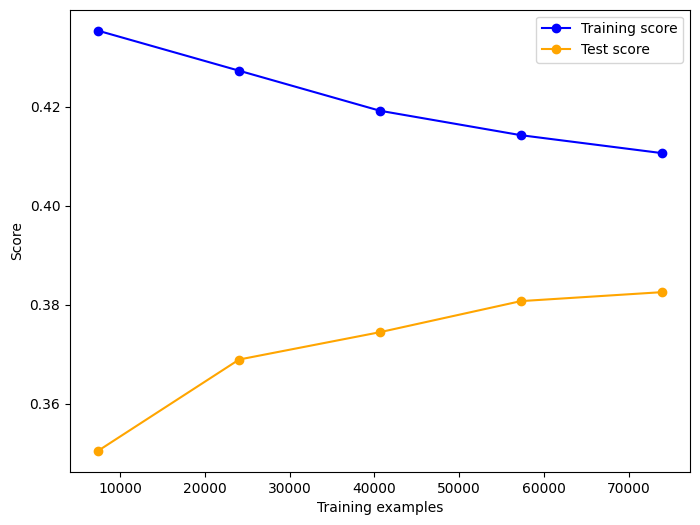

In [27]:
# Disegna le curve di apprendimento per valutare le prestazioni del modello al variare della dimensione
# del set di addestramento e confronta le prestazioni sul set di addestramento e di test.

from sklearn.model_selection import learning_curve

plt.figure(
    figsize=(8, 6)
)  # Modifica le dimensioni come desiderato (larghezza, altezza)
train_sizes, train_scores, test_scores = learning_curve(lgbm, X_train, y_train, cv=5)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, "o-", label="Training score", color="blue")
plt.plot(train_sizes, test_scores_mean, "o-", label="Test score", color="orange")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.


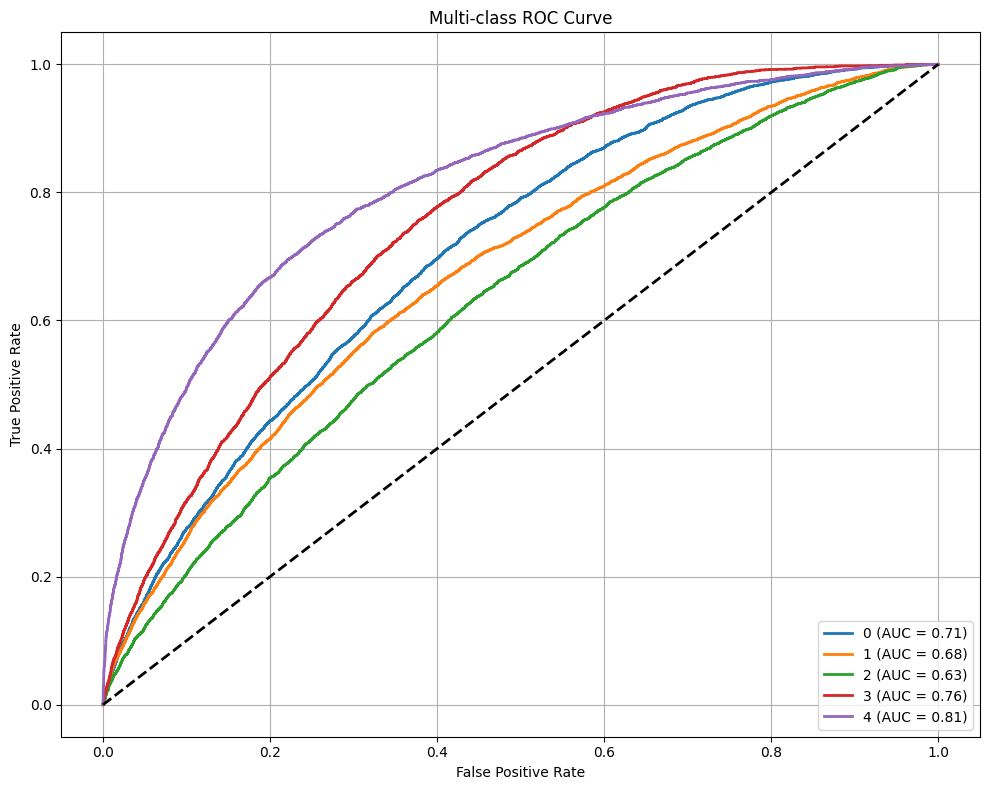

In [29]:
y_score_lgbm = lgbm.predict_proba(X_test)
utils.plot_multiclass_roc(y_test, y_score_lgbm, class_names=classes)


array([[2748,  438,  419,  987,  517],
       [1119, 1232,  396,  515, 1486],
       [1841,  761,  553,  633,  722],
       [1711,  215,  202, 1474,  390],
       [ 510,  754,  175,  446, 2858]])

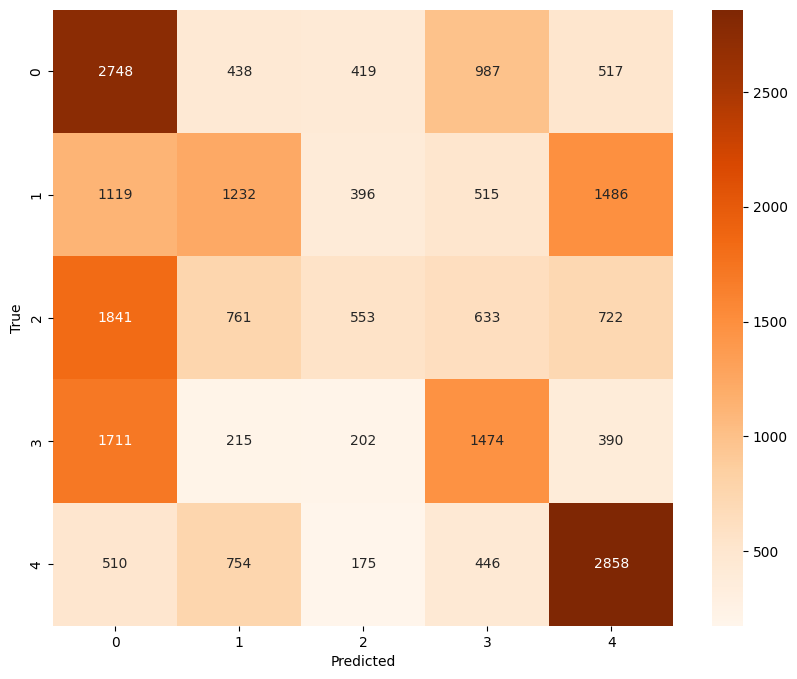

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("True")
cm

In [31]:
"""
# Make predictions on test data
y_pred_proba = lgbm.predict_proba(X_test)  # Probability estimates of each class

# Binarize the labels
y_test_binarized = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_binarized.shape[1]

# Compute precision and recall for each class
precision = dict()
recall = dict()
thresholds = dict()
auc_score = dict()

for i in range(n_classes):
    precision[i], recall[i], thresholds[i] = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    auc_score[i] = auc(recall[i], precision[i])

# Plot precision-recall curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Class {i} (AUC = {auc_score[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
#plt.title('Precision-Recall Curve for Multiclass Classification')
plt.legend(loc='lower left')
#plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()
"""

"\n# Make predictions on test data\ny_pred_proba = lgbm.predict_proba(X_test)  # Probability estimates of each class\n\n# Binarize the labels\ny_test_binarized = label_binarize(y_test, classes=np.unique(y))\nn_classes = y_test_binarized.shape[1]\n\n# Compute precision and recall for each class\nprecision = dict()\nrecall = dict()\nthresholds = dict()\nauc_score = dict()\n\nfor i in range(n_classes):\n    precision[i], recall[i], thresholds[i] = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i])\n    auc_score[i] = auc(recall[i], precision[i])\n\n# Plot precision-recall curve for each class\nplt.figure(figsize=(10, 8))\nfor i in range(n_classes):\n    plt.plot(recall[i], precision[i], label=f'Class {i} (AUC = {auc_score[i]:.2f})')\n\nplt.xlabel('Recall')\nplt.ylabel('Precision')\n#plt.title('Precision-Recall Curve for Multiclass Classification')\nplt.legend(loc='lower left')\n#plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))\nplt.grid(True)\nplt.show()\n"

plot tutti e due


In [32]:
# Vado anche a plottare l'accuracy del modello rispetto al numero di stimatori
max_k = 200
acc_xgb = []
acc_lgb = []

for k in range(20, max_k + 1, 5):
    xgb1 = XGBClassifier(
        n_estimators=k,
        objective="binary:logistic",
        reg_lambda=1.0,
        reg_alpha=1.0,
        max_depth=7,
        learning_rate=0.01,
        booster="gbtree",
        tree_method="exact",
        subsample=0.8,
        colsample_bytree=0.6,
    )
    lgb1 = LGBMClassifier(
        n_estimators=k,
        subsample_for_bin=200000,
        reg_lambda=0.5,
        reg_alpha=0.0,
        objective="multiclass",
        num_leaves=15,
        min_data_in_leaf=2000,
        max_depth=7,
        learning_rate=0.05,
        boosting_type="gbdt",
    )
    xgb1.fit(X_train, y_train)
    lgb1.fit(X_train, y_train)

    y_pred_xgb1 = xgb1.predict(X_test)
    y_pred_gbc1 = lgb1.predict(X_test)

    acc_xgb.append(accuracy_score(y_test, y_pred_xgb1))
    acc_lgb.append(accuracy_score(y_test, y_pred_gbc1))
    print(f"{k}th fit done")

[LightGBM] [Warning] min_data_in_leaf is set=2000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=2000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1418
[LightGBM] [Info] Number of data points in the train set: 92405, number of used features: 42
[LightGBM] [Info] Start training from score -1.509079
[LightGBM] [Info] Start training from score -1.582163
[LightGBM] [Info] Start training from score -1.633590
[LightGBM] [Info] Start training from score -1.755532
[LightGBM] [Info] Start training from score -1.583217
[LightGBM] [Warning] min_data_in_leaf is set=

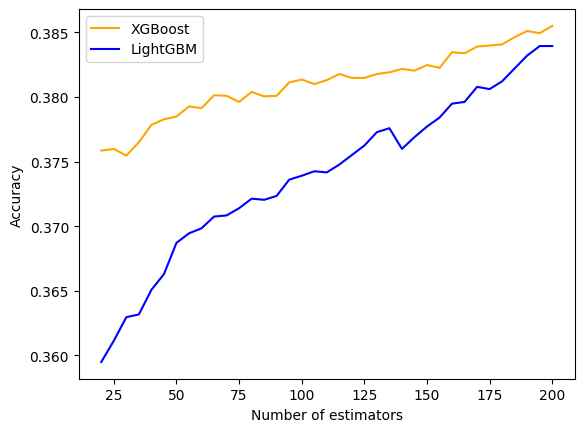

In [33]:
k_values = list(range(20, 201, 5))

# Plotting
plt.plot(k_values, acc_xgb, label="XGBoost", color="orange")
plt.plot(k_values, acc_lgb, label="LightGBM", color="blue")


# Adding labels and title
plt.xlabel("Number of estimators")
plt.ylabel("Accuracy")

# Adding a legend
plt.legend()

# plt.ylim(0.48, 0.52)  # Replace 0 and 1 with your desired y-axis range

# Display the plot
plt.show()